In [6]:
# Import public packages and functions
import os
import pandas as pd
import numpy as np
import sys
import json
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
import scikit_posthocs as sp

import warnings
warnings.filterwarnings("ignore")

# inserting the lib folder to the compiler
sys.path.insert(0, './lib')
sys.path.insert(0, './utils/')

import utils_misc, utils_io, utils_plotting, utils_mutual_information, utils_statistics, utils_spectrogram, utils_plotting_spectrogram
from lib_data import DATA_IO

fs        = 2048
PATH_CURR = os.path.abspath(os.curdir)    # current code
PATH      = (str(Path(PATH_CURR).parent)) # data repository: upper directory where datasets situated

In [8]:
df_TAPPING_MOTOR_events = pd.read_pickle(DATA_IO.path_events + "LFP_TAPPING_EVENTS_MOTOR_AREA.pkl")
df_TAPPING_MOTOR_events.patient.unique()

array(['008', '009', '012', '013', '014', '017', '019', '020', '021',
       '022', '023', '102', '103', '105', '108', '109', '110'],
      dtype=object)

# 1. Calculate Tap-Wise Time-Frequency Activity

In [3]:
df_TAPPING_MOTOR_events = pd.read_pickle(DATA_IO.path_events + "LFP_TAPPING_EVENTS_MOTOR_AREA.pkl")

## LID severity 3: noLID_noDOPA, noLID_DOPA, LID
df_TAPPING_MOTOR_events["LID"] = df_TAPPING_MOTOR_events.dyskinesia_arm.copy()
df_TAPPING_MOTOR_events.loc[(df_TAPPING_MOTOR_events['LID']!= "none")  , "LID"]          = 'LID'
df_TAPPING_MOTOR_events.loc[(df_TAPPING_MOTOR_events['LID']== "none") &
                            (df_TAPPING_MOTOR_events['event_start_time'] <= 30 ), "LID"] = 'noLID_noDOPA'
df_TAPPING_MOTOR_events.loc[(df_TAPPING_MOTOR_events['LID']== "none") & 
                            (df_TAPPING_MOTOR_events['event_start_time'] > 30 ) , "LID"] = 'noLID_DOPA'

df_controlateral        = df_TAPPING_MOTOR_events[df_TAPPING_MOTOR_events.event_laterality != df_TAPPING_MOTOR_events.LFP_hemisphere]
df_controlateral        = utils_misc.get_onset_and_offset_aligned_recordings(df_controlateral, fs=fs)
df_controlateral        = df_controlateral[["patient", "event_no", "LFP_hemisphere", "LFP_channel", "recording_onset_aligned","recording_offset_aligned","LID"]]
df_controlateral.reset_index(inplace=True, drop=True)

baseline_recordings     = utils_io.load_baseline_recordings(recording_type="LFP")

In [5]:
dataset                 = pd.DataFrame(df_controlateral)
dataset["hemisphere"]   = dataset.LFP_hemisphere
dataset["channel"]      = dataset.LFP_channel
dataset.reset_index(inplace=True, drop=True)

df_spectrogram          = utils_spectrogram.measure_normalized_multitaper_spectrograms_for_taps(dataset, fs, baseline_recordings)
df_spectrogram.to_pickle(DATA_IO.path_events + "time_frequency_activity/LFP_TFA") 

Patient 008
>> right hemisphere : 05-02 channel is excluded!
>> right hemisphere : 06-03 channel is excluded!
>> right hemisphere : 07-04 channel is excluded!
>> right hemisphere : 08-05 channel is excluded!
>> right hemisphere : 09-06 channel is excluded!
>> right hemisphere : 10-07 channel is excluded!
---> baseline TFR measurement is completed...
------> left - LID - p_008_right_tapping1
------> left - LID - p_008_right_tapping2
------> left - LID - p_008_right_tapping3
------> left - LID - p_008_right_tapping4
------> left - LID - p_008_right_tapping5
------> left - LID - p_008_right_tapping6
------> left - LID - p_008_right_tapping7
------> left - LID - p_008_right_tapping8
------> left - LID - p_008_right_tapping9
------> left - LID - p_008_right_tapping10
------> left - LID - p_008_right_tapping11
------> left - LID - p_008_right_tapping12
------> left - LID - p_008_right_tapping13
------> left - LID - p_008_right_tapping14
------> left - LID - p_008_right_tapping15
------> left

# 2. Load Channel and Severity-Wise Time-Frequency Activity

In [3]:
df_spectrogram              = pd.read_pickle(DATA_IO.path_events + "time_frequency_activity/LFP_TFA") 
df_spectrogram_noLID_noDOPA = df_spectrogram[df_spectrogram.severity=="noLID_noDOPA"]
df_spectrogram_noLID_DOPA   = df_spectrogram[df_spectrogram.severity=="noLID_DOPA"]
df_spectrogram_LID          = df_spectrogram[df_spectrogram.severity=="LID"]

# filtering 
df_spectrogram_noLID_noDOPA = df_spectrogram_noLID_noDOPA[df_spectrogram_noLID_noDOPA.patient.isin(df_spectrogram_noLID_noDOPA.patient.value_counts()[lambda x: x >= 10].index)]
df_spectrogram_noLID_DOPA   = df_spectrogram_noLID_DOPA[df_spectrogram_noLID_DOPA.patient.isin(df_spectrogram_noLID_DOPA.patient.value_counts()[lambda x: x >= 10].index)]
df_spectrogram_LID          = df_spectrogram_LID[df_spectrogram_LID.patient.isin(df_spectrogram_LID.patient.value_counts()[lambda x: x >= 10].index)]

# 3. Plot Spectrograms

In [12]:
# measure mean spectrograms
TFR_avg_onset_noLID_noDOPA  = np.nanmean(list(df_spectrogram_noLID_noDOPA[df_spectrogram_noLID_noDOPA["onset_aligned_normalized"].apply(lambda x: isinstance(x, np.ndarray))].onset_aligned_normalized), axis=0)
TFR_avg_offset_noLID_noDOPA = np.nanmean(list(df_spectrogram_noLID_noDOPA[df_spectrogram_noLID_noDOPA["offset_aligned_normalized"].apply(lambda x: isinstance(x, np.ndarray))].offset_aligned_normalized), axis=0)
TFR_avg_onset_noLID_DOPA    = np.nanmean(list(df_spectrogram_noLID_DOPA[df_spectrogram_noLID_DOPA["onset_aligned_normalized"].apply(lambda x: isinstance(x, np.ndarray))].onset_aligned_normalized), axis=0)
TFR_avg_offset_noLID_DOPA   = np.nanmean(list(df_spectrogram_noLID_DOPA[df_spectrogram_noLID_DOPA["offset_aligned_normalized"].apply(lambda x: isinstance(x, np.ndarray))].offset_aligned_normalized), axis=0)
TFR_avg_onset_LID           = np.nanmean(list(df_spectrogram_LID[df_spectrogram_LID["onset_aligned_normalized"].apply(lambda x: isinstance(x, np.ndarray))].onset_aligned_normalized), axis=0)
TFR_avg_offset_LID          = np.nanmean(list(df_spectrogram_LID[df_spectrogram_LID["offset_aligned_normalized"].apply(lambda x: isinstance(x, np.ndarray))].offset_aligned_normalized), axis=0)

# remove extra dimension: from  (1, 87, 8192) to (87, 8192)
TFR_avg_onset_noLID_noDOPA  = np.squeeze(TFR_avg_onset_noLID_noDOPA) 
TFR_avg_offset_noLID_noDOPA = np.squeeze(TFR_avg_offset_noLID_noDOPA) 
TFR_avg_onset_noLID_DOPA    = np.squeeze(TFR_avg_onset_noLID_DOPA) 
TFR_avg_offset_noLID_DOPA   = np.squeeze(TFR_avg_offset_noLID_DOPA) 
TFR_avg_onset_LID           = np.squeeze(TFR_avg_onset_LID) 
TFR_avg_offset_LID          = np.squeeze(TFR_avg_offset_LID) 

<Figure size 640x480 with 0 Axes>

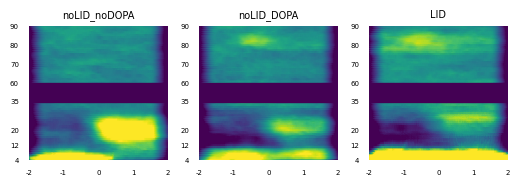

In [49]:
plt             = utils_plotting.get_figure_template()
ax_noLID_noDOPA = plt.subplot2grid((80, 40), (0, 0) , colspan=10, rowspan=17)
ax_noLID_DOPA   = plt.subplot2grid((80, 40), (0, 12) , colspan=10, rowspan=17)
ax_LID          = plt.subplot2grid((80, 40), (0, 24), colspan=10, rowspan=17)

ax_noLID_noDOPA = utils_plotting_spectrogram.plot_mean_spectrogram(TFR_avg_offset_noLID_noDOPA, group = "noLID_noDOPA", time_vector=np.linspace(-2,2,fs*4), 
                                                                   vmin=-40, vmax=40, cmap="viridis", axis=ax_noLID_noDOPA)
ax_noLID_DOPA   = utils_plotting_spectrogram.plot_mean_spectrogram(TFR_avg_offset_noLID_DOPA, group = "noLID_DOPA", time_vector=np.linspace(-2,2,fs*4), 
                                                                   vmin=-40, vmax=40, cmap="viridis", axis=ax_noLID_DOPA)
ax_LID          = utils_plotting_spectrogram.plot_mean_spectrogram(TFR_avg_offset_LID, group = "LID", time_vector=np.linspace(-2,2,fs*4), 
                                                                   vmin=-40, vmax=40, cmap="viridis", axis=ax_LID)

plt.savefig(DATA_IO.path_figure + "spectrogram/motor_stn_spectrogram_offset.svg", dpi=1200)

In [44]:
def plot_permutation_clusters_on_spectrogram(F_stats, clusters, cluster_p_values, alpha, time_vector, cmap, vmax, axis):

    significance_mask = np.nan * np.ones_like(F_stats)
    for c, p_val in zip(clusters, cluster_p_values):
        if (p_val <= alpha):
            row_indices = c[0]  # Use c[0] for rows
            col_indices = c[1]  # Use c[1] for columns
            significance_mask[row_indices, col_indices] = F_stats[row_indices, col_indices]
        
    freq_changed = []
    for x in np.arange(4, 91):
        if((x>=35) and (x<60)):
            freq_changed.append(35+((x-35)/2.5))
        elif(x>=60):
            freq_changed.append(x-15)
        else:
            freq_changed.append(x)

    mesh = axis.pcolormesh(time_vector, freq_changed, F_stats, shading='auto', cmap=cmap, vmax=vmax, rasterized=True)
    axis.pcolormesh(time_vector, freq_changed, significance_mask, shading='gouraud', cmap=cmap, vmax=vmax, rasterized=True)
    axis.set_xticks([-2,-1,0,1,2], [-2,-1,0,1,2], fontsize =utils_plotting.LABEL_SIZE)
    axis.set_yticks([4,12,20,35,45,55,65,75], [4,12,20,35,60,70,80,90], fontsize =utils_plotting.LABEL_SIZE)
    axis.set_title("", fontsize=utils_plotting.LABEL_SIZE_title)

    # cover the frequencies from 35 to 60 Hz
    cmap      = plt.get_cmap(cmap)
    norm      = mcolors.Normalize(vmin=0, vmax=1)
    low_color = cmap(norm(0)) 
    axis.axhspan(35, 45, color=low_color, alpha=1)
    
    axis.spines.left.set_visible(False)
    axis.spines.bottom.set_visible(False)
    axis.spines.right.set_visible(False)
    axis.spines.top.set_visible(False)
    axis.xaxis.set_ticks_position('none')  # Hide the x-axis ticks
    axis.yaxis.set_ticks_position('none')  # Hide the y-axis ticks
    
    return axis, mesh

In [46]:
F_stats, clusters, cluster_p_values, H0 = permutation_cluster_test(data, adjacency=adjacency, n_permutations=1000, tail=0)

Using a threshold of 3.993365
stat_fun(H1): min=5.514435003458967e-08 max=22.375790680768556
Running initial clustering …
Found 64 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

<Figure size 640x480 with 0 Axes>

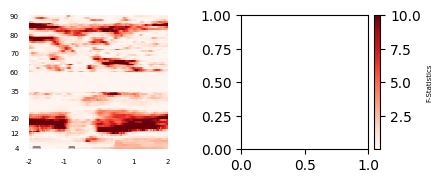

In [47]:
plt      = utils_plotting.get_figure_template()
ax_fstat = plt.subplot2grid((80, 40), (0, 0) , colspan=10, rowspan=17)
ax_cbar  = plt.subplot2grid((80, 40), (0, 15), colspan=10, rowspan=17)

ax_fstat, mesh = utils_plotting_spectrogram.plot_permutation_clusters_on_spectrogram(F_stats, clusters, cluster_p_values, alpha=0.05, 
                                                                                     time_vector=np.linspace(-2,2,256), cmap="Reds", vmax=10, axis=ax_fstat)
cbar1 = plt.colorbar(mesh, ax=ax_cbar, orientation='vertical', fraction=0.05, pad=0.04)
cbar1.set_label("F-Statistics", fontsize=utils_plotting.LABEL_SIZE)

In [52]:
cluster_p_values

array([0.993, 0.037, 0.003, 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       0.792, 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 0.838,
       0.986, 1.   , 1.   , 1.   , 1.   , 0.996, 1.   , 0.596, 0.274,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 0.117, 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 0.996, 1.   , 0.996, 0.99 , 1.   ,
       1.   , 1.   , 0.33 , 0.942, 0.021, 1.   , 1.   , 1.   , 1.   ,
       1.   ])

Using a threshold of 4.012973
stat_fun(H1): min=1.1453379581310698e-08 max=28.260908545038617
Running initial clustering …
Found 47 clusters


  0%|          | Permuting : 0/499 [00:00<?,       ?it/s]

<Figure size 640x480 with 0 Axes>

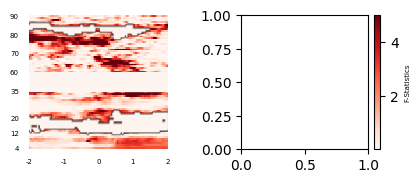

In [127]:
# get average spectrogram for defined severity for each patient
T_obs, clusters, clusters_pvals = utils_spectrogram.run_permutation_cluster_with_downsampling(avg_spectrograms_LID, 
                                                                                              avg_spectrograms_noLID_noDOPA,
                                                                                              target_time_points=100, 
                                                                                              n_permutations=500, tail=0, n_jobs=1)
plt      = utils_plotting.get_figure_template()
ax_fstat = plt.subplot2grid((80, 40), (0, 0) , colspan=10, rowspan=17)
ax_cbar  = plt.subplot2grid((80, 40), (0, 15), colspan=10, rowspan=17)

ax_fstat, mesh = utils_plotting_spectrogram.plot_permutation_clusters_on_spectrogram(T_obs, clusters, clusters_pvals, alpha=0.05, 
                                                                                     time_vector=np.linspace(-2,2,100), cmap="Reds", vmax=5, axis=ax_fstat)
cbar1 = plt.colorbar(mesh, ax=ax_cbar, orientation='vertical', fraction=0.05, pad=0.04)
cbar1.set_label("F-Statistics", fontsize=utils_plotting.LABEL_SIZE)

plt.savefig(DATA_IO.path_figure + "spectrogram/motor_stn_permutation_clustering_noLIDnoDOPA_vs_LID.svg", dpi=1200)

In [113]:
# Set your significance threshold
p_threshold = 0.05

# Create a mask with the same shape as T_obs, initialized as False
significance_mask = np.zeros_like(T_obs, dtype=bool)

# Combine significant clusters into one mask
for cluster, p_val in zip(clusters, clusters_pvals):
    if p_val < p_threshold:
        significance_mask[cluster] = True

# Plotting
plt.figure(figsize=(12, 6))

# Show T_obs
plt.imshow(T_obs, aspect='auto', origin='lower', cmap='RdBu_r',
           extent=[0, T_obs.shape[1], 0, T_obs.shape[0]])
plt.colorbar(label='T-values')
plt.title('T-map with Significant Clusters')

# Overlay significant mask
masked = np.ma.masked_where(~significance_mask, significance_mask)
plt.imshow(masked, aspect='auto', origin='lower', cmap='Greens', alpha=0.4,
           extent=[0, T_obs.shape[1], 0, T_obs.shape[0]])

plt.xlabel('Time (samples or seconds)')
plt.ylabel('Frequency bins')
plt.tight_layout()
plt.show()

IndexError: index 842 is out of bounds for axis 0 with size 87

### 4.1.1 NoLID_NoDOPA vs NoLID_DOPA

### 4.1.2 NoLID_NoDOPA vs LID

In [20]:
df_spectrogram_LID["dyskinesia_group"]    = 1 # assign numeric value 1 to dyskinetic event
df_spectrogram_noLID["dyskinesia_group"]  = 0 # assign numeric value 0 to dyskinetic event

# concat two dataframes (no-LID and LID)
df_offset_aligned = pd.concat([df_spectrogram_LID[["offset_aligned_normalized","dyskinesia_group"]], 
                               df_spectrogram_noLID[["offset_aligned_normalized","dyskinesia_group"]]], 
                              ignore_index=True)

# rename the column
df_offset_aligned["spectrogram"] = df_offset_aligned["offset_aligned_normalized"]
df_offset_aligned                = df_offset_aligned[["spectrogram", "dyskinesia_group"]]
df_offset_aligned                = df_offset_aligned.dropna(subset=['spectrogram']) # removing nan spectrogram  

# downsample spectrograms with means to reduce time resolution for mutual information calculation
downsampled_spectrograms = []
for index,row in df_offset_aligned.iterrows():
    downsampled_spectrograms.append(utils_misc.spectrogram_downsampling_with_mean(row.spectrogram, fs=2048, time_interval_in_second=0.02)) # 20 ms. bins
    
df_offset_aligned["spectrogram"] = downsampled_spectrograms

n_rows = np.shape(df_offset_aligned.iloc[0].spectrogram)[0]
n_cols = np.shape(df_offset_aligned.iloc[0].spectrogram)[1]

print(str(n_rows) +  " x " + str(n_cols)) # time datapoints dropped from 8192 to 204

87 x 204


Each spectrogram contains 87 frequency components (frequency resolution 1 from 4 to 90 Hz) and 204 (binned with 20 ms)
time points equal to 4 seconds time period around event onset/offset [-2 seconds to +2 seconds]

##  5.1 Measure Mutual Information and Significance

In [22]:
matrix_MI, matrix_MI_pvalues, matrix_bootstrap_max = utils_mutual_information.measure_spectrogram_mi(df_offset_aligned, n_iterations=100)

4 Hz mutual information measurement started
5 Hz mutual information measurement started
6 Hz mutual information measurement started
7 Hz mutual information measurement started
8 Hz mutual information measurement started
9 Hz mutual information measurement started
10 Hz mutual information measurement started
11 Hz mutual information measurement started
12 Hz mutual information measurement started
13 Hz mutual information measurement started
14 Hz mutual information measurement started
15 Hz mutual information measurement started
16 Hz mutual information measurement started
17 Hz mutual information measurement started
18 Hz mutual information measurement started
19 Hz mutual information measurement started
20 Hz mutual information measurement started
21 Hz mutual information measurement started
22 Hz mutual information measurement started
23 Hz mutual information measurement started
24 Hz mutual information measurement started
25 Hz mutual information measurement started
26 Hz mutual inf

## 5.2. Save Measured MI and P-Values

In [29]:
with open(DATA_IO.path_events+'mutual_information/LFP/matrix_MI.npy', 'wb') as f: np.save(f, matrix_MI)
with open(DATA_IO.path_events+'mutual_information/LFP/matrix_MI_pvalues.npy', 'wb') as f: np.save(f, matrix_MI_pvalues)
with open(DATA_IO.path_events+'mutual_information/LFP/matrix_bootstrap_max.npy', 'wb') as f: np.save(f, matrix_bootstrap_max)

## 5.3. Load Measured MI and P-Values

In [20]:
matrix_MI              = np.load(DATA_IO.path_events+'mutual_information/LFP/matrix_MI.npy')
matrix_MI_pvalues      = np.load(DATA_IO.path_events+'mutual_information/LFP/matrix_MI_pvalues.npy')
matrix_bootstrap_max   = np.load(DATA_IO.path_events+'mutual_information/LFP/matrix_bootstrap_max.npy')

significance_threshold = np.percentile(matrix_bootstrap_max.flatten(), 95)
MI_significant         = matrix_MI_pvalues>=significance_threshold

## 5.4 Plot Time-Frequency MI

<Figure size 640x480 with 0 Axes>

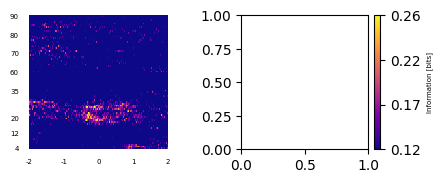

In [28]:
import matplotlib.colors as mcolors

plt        = utils_plotting.get_figure_template()
axis       = plt.subplot2grid((80, 40), (0, 0) , colspan=10, rowspan=17)
ax_cbar    = plt.subplot2grid((80, 40), (0, 15), colspan=10, rowspan=17)
axis, mesh = utils_plotting_spectrogram.plot_spectrogram_MI(matrix_MI, MI_significant, significance_threshold, cmap="plasma", axis=axis)

mesh.set_clim(significance_threshold, np.max(matrix_MI))
cbar1 = plt.colorbar(mesh, ax=ax_cbar, orientation='vertical', fraction=0.05, pad=0.04)
custom_ticks = np.linspace(significance_threshold, np.max(matrix_MI), 4)
cbar1.set_ticks(custom_ticks)
cbar1.set_ticklabels([f"{tick:.2f}" for tick in custom_ticks])
cbar1.set_label("Information [bits]", fontsize=utils_plotting.LABEL_SIZE)

plt.savefig(DATA_IO.path_figure + 'mutual_information/motor_stn_spectrogram_MI.svg', dpi=1200)